# Prediction task to determine whether a person makes over 50k a year.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

## Loading the Data
This dataset comes from the 1994 US Census Bureau and contains ~48,000 
records. The goal is to predict whether a person's income exceeds 
$50,000/year based on demographic and employment attributes.

In [6]:
df = pd.read_csv('adult.csv', names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native country', 'Class'])

In [7]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native country,Class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native country    0
Class             0
dtype: int64

## Exploring the Data
Before modeling, I looked at how income is distributed across the 
dataset and across demographic groups like sex and race. This helps 
spot class imbalance (roughly 75/25 here) and surfaces patterns worth 
keeping in mind when interpreting model results later.

<Axes: xlabel='Class', ylabel='count'>

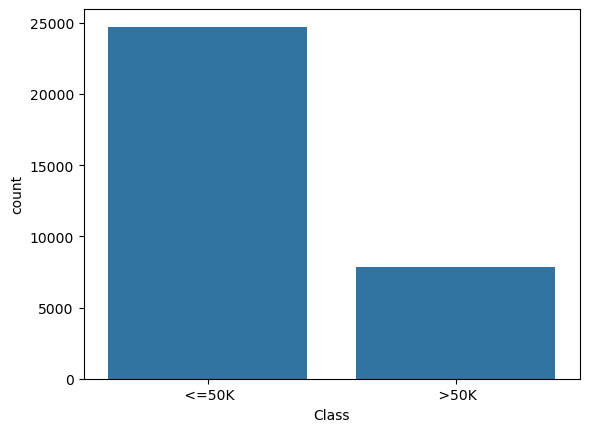

In [9]:
sns.countplot(data=df, x='Class')

<Axes: xlabel='Class', ylabel='count'>

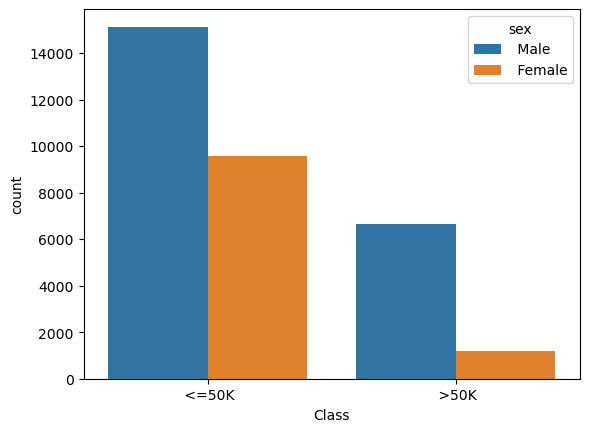

In [10]:
sns.countplot(data=df, x='Class', hue='sex')

<Axes: xlabel='Class', ylabel='count'>

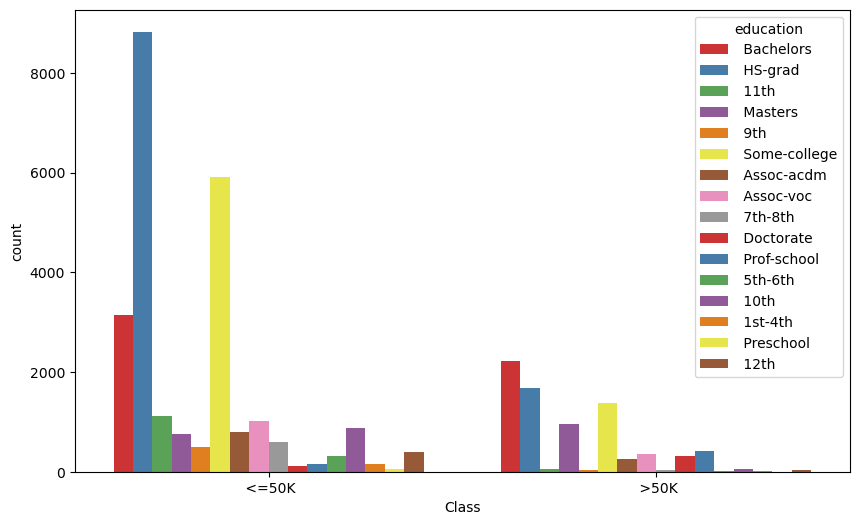

In [11]:
plt.figure(figsize=(10,6), dpi=100)
sns.countplot(data=df, x='Class', hue='education', palette='Set1')

<Axes: xlabel='Class', ylabel='count'>

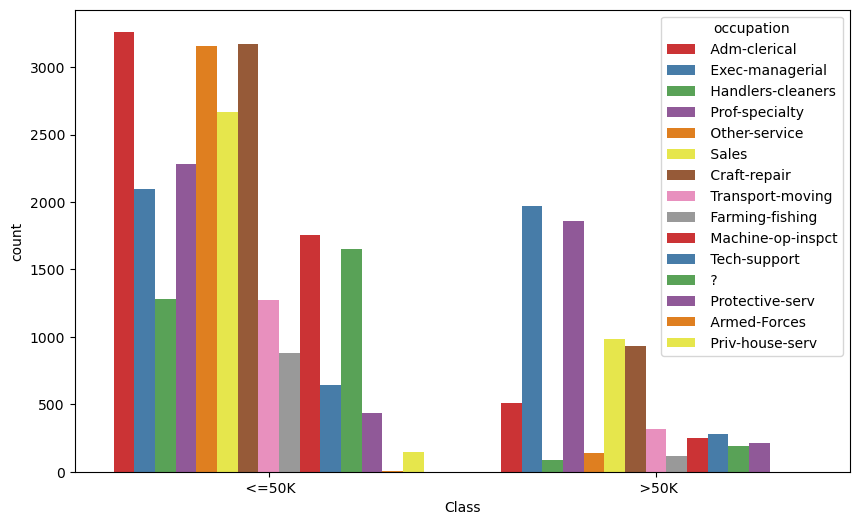

In [12]:
plt.figure(figsize=(10,6), dpi=100)
sns.countplot(data=df, x='Class', hue='occupation', palette='Set1')

<Axes: xlabel='Class', ylabel='count'>

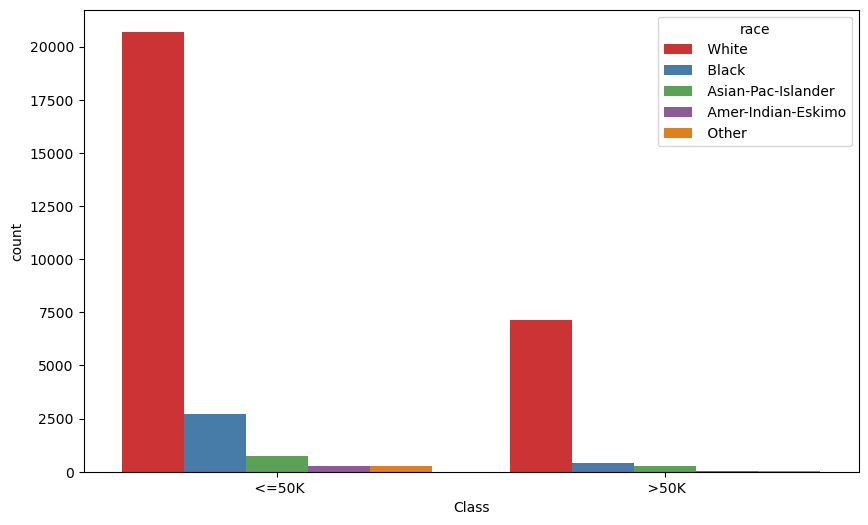

In [13]:
plt.figure(figsize=(10,6), dpi=100)
sns.countplot(data=df, x='Class', hue='race', palette='Set1')

## Preparing the Data
Here I separate the features from the target, convert categorical 
columns into a numeric format the models can use, split the data into 
training/test sets, and scale the numeric features. I also wrote a 
reusable `run_model()` function so every algorithm below is trained 
and evaluated the same way — for a fair comparison.

In [14]:
X = df.drop(['Class'], axis=1)
y = df['Class']

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [18]:
scaler = StandardScaler()

In [19]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [21]:
def run_model(model,X_train,y_train,X_test,y_test):
    
    
    model.fit(X_train,y_train)
    
    preds = model.predict(X_test)
    
    print(classification_report(y_test, preds))
    ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [23]:
len(scaled_X_test)

9769

##  Comparing Models
Rather than picking one algorithm upfront, I trained and evaluated five different classifiers to see which handles this data best.

## KNN

              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.88      7436
        >50K       0.64      0.58      0.61      2333

    accuracy                           0.82      9769
   macro avg       0.75      0.74      0.75      9769
weighted avg       0.82      0.82      0.82      9769



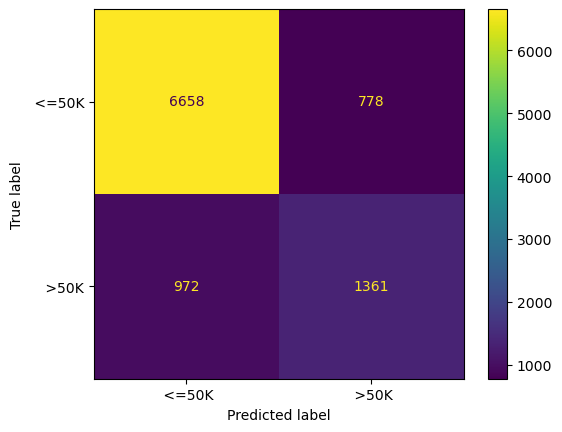

In [24]:
model = KNeighborsClassifier()
run_model(model,scaled_X_train,y_train,scaled_X_test,y_test)

## SVC

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7436
        >50K       0.74      0.58      0.65      2333

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



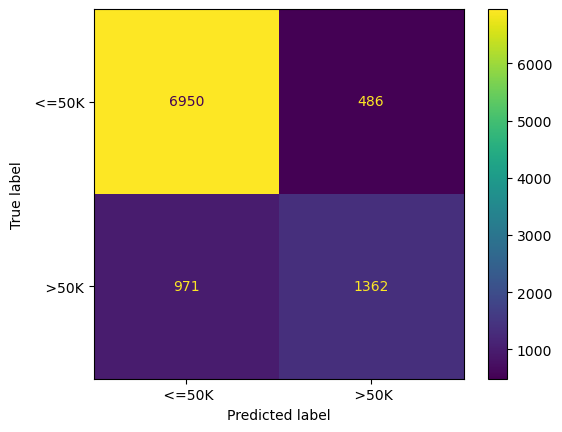

In [25]:
model = SVC()
run_model(model,scaled_X_train,y_train,scaled_X_test,y_test)

## Decision Trees

              precision    recall  f1-score   support

       <=50K       0.89      0.87      0.88      7436
        >50K       0.61      0.64      0.63      2333

    accuracy                           0.82      9769
   macro avg       0.75      0.76      0.75      9769
weighted avg       0.82      0.82      0.82      9769



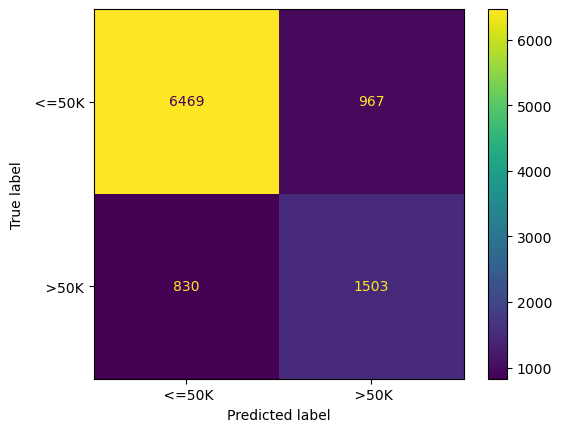

In [26]:
model = DecisionTreeClassifier()
run_model(model,X_train,y_train,X_test,y_test)

## Random Forest

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7436
        >50K       0.73      0.63      0.68      2333

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



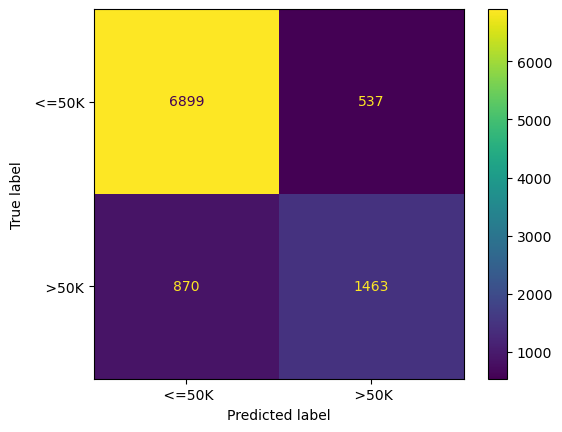

In [27]:
model = RandomForestClassifier()
run_model(model,X_train,y_train,X_test,y_test)

## AdaBoost

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7436
        >50K       0.76      0.59      0.66      2333

    accuracy                           0.86      9769
   macro avg       0.82      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769



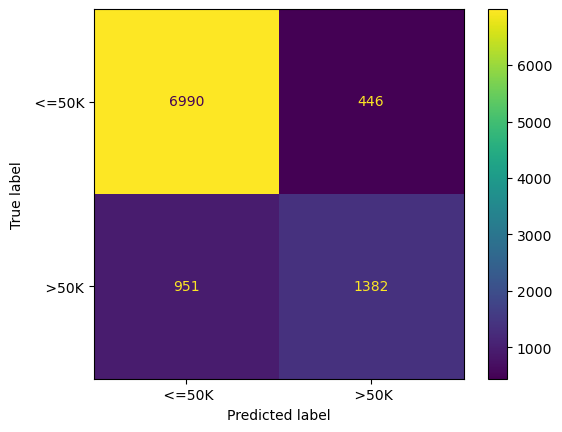

In [28]:
model = AdaBoostClassifier()
run_model(model,X_train,y_train,X_test,y_test)

## GradBoost

              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7436
        >50K       0.79      0.63      0.70      2333

    accuracy                           0.87      9769
   macro avg       0.84      0.79      0.81      9769
weighted avg       0.87      0.87      0.87      9769



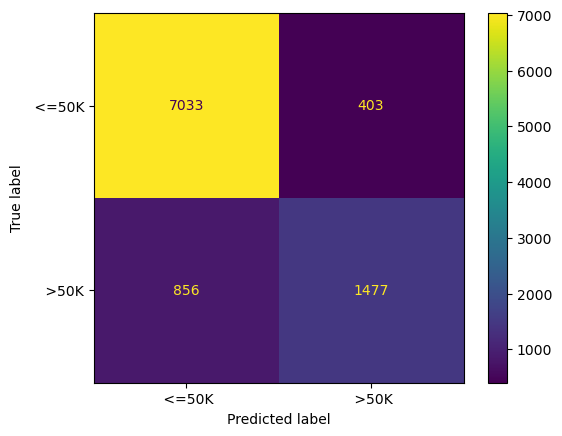

In [29]:
model = GradientBoostingClassifier()
run_model(model,X_train,y_train,X_test,y_test)

##  Tuning the Best Model
Gradient Boosting (GradBoost) performed best out of the box, so I used 
GridSearchCV to search across learning rates and number of estimators 
to squeeze out further improvement — landing on 87% accuracy with 
better recall on the >$50K class.

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {'learning_rate': [0.1, 0.2], 'n_estimators': [50, 100, 150, 200]}

In [32]:
grad = GradientBoostingClassifier()
grad_grid = GridSearchCV(grad, param_grid)

In [33]:
grad_grid.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.1, 0.2], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [34]:
grad_grid.best_params_

{'learning_rate': 0.2, 'n_estimators': 200}

In [35]:
grid_preds = grad_grid.predict(X_test)

              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      7436
        >50K       0.78      0.66      0.72      2333

    accuracy                           0.87      9769
   macro avg       0.84      0.80      0.82      9769
weighted avg       0.87      0.87      0.87      9769



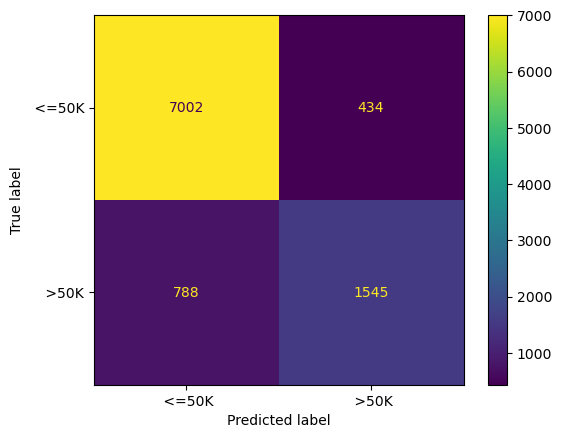

In [36]:
print(classification_report(y_test, grid_preds))
ConfusionMatrixDisplay.from_predictions(y_test, grid_preds)

In [37]:
df.to_csv("Final_Adult_Model.csv", index=False)